<a href="https://colab.research.google.com/github/jayvazil/datasciencepracticumgrp3/blob/main/predictionpromalaria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [ ]:
df=pd.read_csv('/content/Final_Malaria_Dataset.csv')

In [ ]:
df.head()

,Region,County,Year,Month,Population,Rainfall_mm,Temperature_C,Humidity_percent,Malaria_Cases,Lag_1_Month_Cases,Incidence_per_100k,High_Risk_Binary,ID,Health_Facilities,Avg_Income,Disease_Cases,Notes
0,Central Region,Nyeri,2025,2,800000,153.73,23.13,64.03,1105,1183,138.12,0,NaN,NaN,NaN,NaN,NaN
1,Nyanza Region,Kisii,2024,7,1300000,97.42,29.06,73.79,1546,1660,118.92,0,NaN,NaN,NaN,NaN,NaN
2,Central Region,Kirinyaga,2022,8,700000,45.75,19.42,65.25,703,1069,100.43,0,NaN,NaN,NaN,NaN,NaN
3,Central Region,Kirinyaga,2022,4,700000,216.04,17.40,61.35,1215,1533,173.57,1,NaN,NaN,NaN,NaN,NaN
4,Nyanza Region,Homa Bay,2023,11,1100000,137.25,27.44,71.69,1605,1784,145.91,0,NaN,NaN,NaN,NaN,NaN


In [ ]:
df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Month"].astype(str))

df = df.sort_values("Date")

In [ ]:
X = df[["Temperature_C", "Rainfall_mm", "Humidity_percent"]]
y = df["Malaria_Cases"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [ ]:
predictions = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error

error = mean_absolute_error(y_test, predictions)

print("Model Error:", error)

Model Error: 437.5238333333334


In [ ]:
import joblib

joblib.dump(model, "malaria_model.pkl")

['malaria_model.pkl']

In [ ]:
pip install pandas numpy scikit-learn matplotlib prophet autots openpyxl joblib

In [ ]:
print(df.columns)

Index(['Region', 'County', 'Year', 'Month', 'Population', 'Rainfall_mm',
       'Temperature_C', 'Humidity_percent', 'Malaria_Cases',
       'Lag_1_Month_Cases', 'Incidence_per_100k', 'High_Risk_Binary', 'ID',
       'Health_Facilities', 'Avg_Income', 'Disease_Cases', 'Notes', 'Date'],
      dtype='object')


In [ ]:
predictions = model.predict(X_test)

print(predictions[:10])

[1150.9  1254.23 1285.9  1319.83 1460.29 1232.79 1372.71 1128.3  1064.17
 1579.06]


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 437.5238333333334
R2 Score: -0.05204460525268195


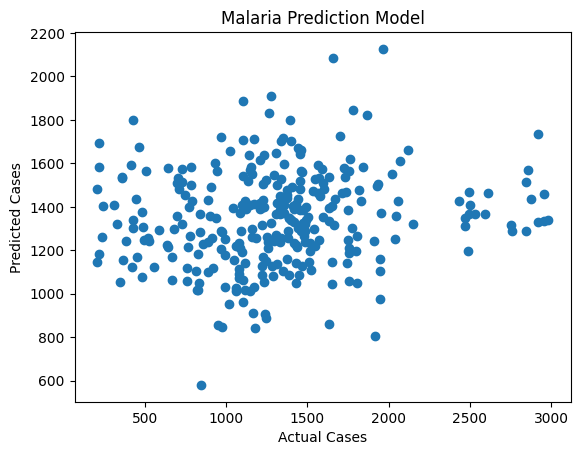

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)
plt.xlabel("Actual Cases")
plt.ylabel("Predicted Cases")
plt.title("Malaria Prediction Model")
plt.show()

In [ ]:
import joblib

joblib.dump(model, "malaria_prediction_model.pkl")

['malaria_prediction_model.pkl']

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


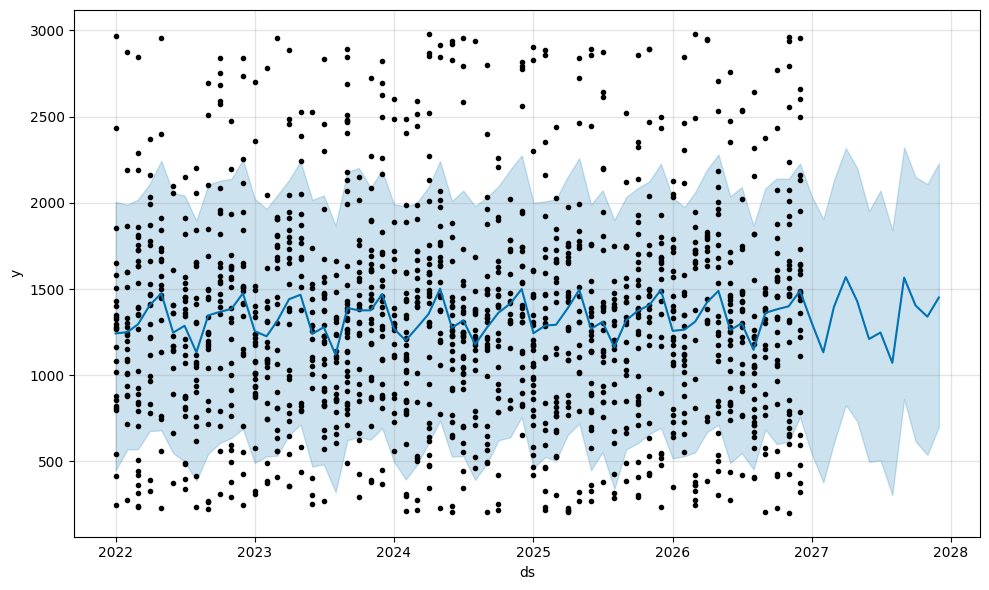

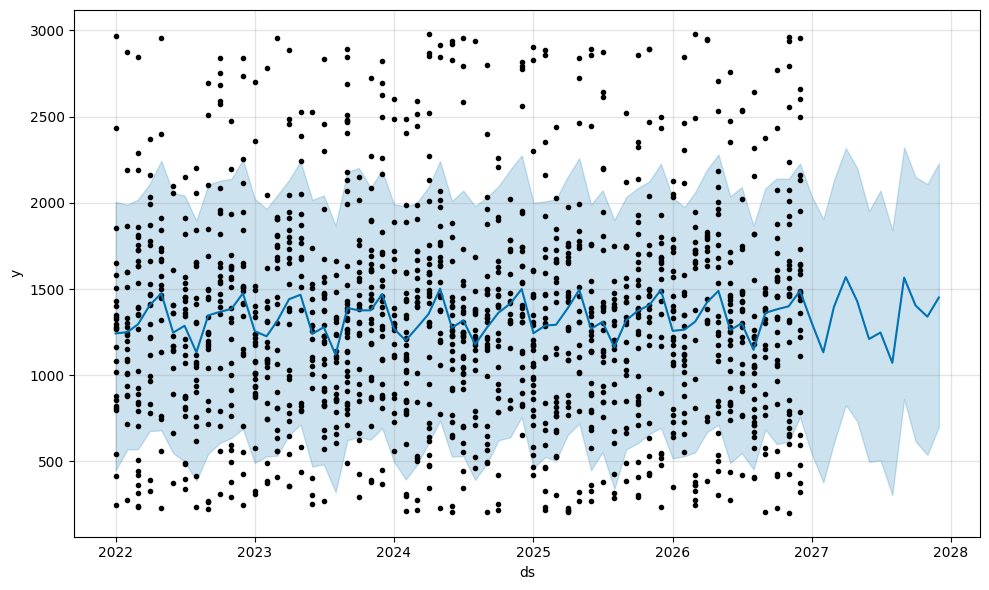

In [ ]:
from prophet import Prophet

prophet_df = df[["Date", "Malaria_Cases"]]
prophet_df.columns = ["ds", "y"]

model_prophet = Prophet()

model_prophet.fit(prophet_df)

future = model_prophet.make_future_dataframe(periods=12, freq="M")

forecast = model_prophet.predict(future)

model_prophet.plot(forecast)